In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

BASE_EEG = Path(r'C:\Users\jeane\Documents\Psychologie\Mental_State')

if BASE_EEG.exists():
    print('✓ Dossier trouvé')
    print('Contenu :', os.listdir(BASE_EEG))
else:
    print('✗ Dossier introuvable — vérifiez le chemin')

✓ Dossier trouvé
Contenu : ['.ipynb_checkpoints', 'mental-state.csv', 'Untitled.ipynb']


In [2]:
df_eeg = pd.read_csv(BASE_EEG / 'mental-state.csv')
print('Shape :', df_eeg.shape)
print('\nColonnes :', df_eeg.columns.tolist())
print('\nAperçu :')
display(df_eeg.head(5))

Shape : (2479, 989)

Colonnes : ['lag1_mean_0', 'lag1_mean_1', 'lag1_mean_2', 'lag1_mean_3', 'lag1_mean_d_h2h1_0', 'lag1_mean_d_h2h1_1', 'lag1_mean_d_h2h1_2', 'lag1_mean_d_h2h1_3', 'lag1_mean_q1_0', 'lag1_mean_q1_1', 'lag1_mean_q1_2', 'lag1_mean_q1_3', 'lag1_mean_q2_0', 'lag1_mean_q2_1', 'lag1_mean_q2_2', 'lag1_mean_q2_3', 'lag1_mean_d_q1q2_0', 'lag1_mean_d_q1q2_1', 'lag1_mean_d_q1q2_2', 'lag1_mean_d_q1q2_3', 'lag1_mean_d_q1q3_0', 'lag1_mean_d_q1q3_1', 'lag1_mean_d_q1q3_2', 'lag1_mean_d_q1q3_3', 'lag1_mean_d_q1q4_0', 'lag1_mean_d_q1q4_1', 'lag1_mean_d_q1q4_2', 'lag1_mean_d_q1q4_3', 'lag1_mean_d_q2q3_0', 'lag1_mean_d_q2q3_1', 'lag1_mean_d_q2q3_2', 'lag1_mean_d_q2q3_3', 'lag1_mean_d_q2q4_0', 'lag1_mean_d_q2q4_1', 'lag1_mean_d_q2q4_2', 'lag1_mean_d_q2q4_3', 'lag1_std_0', 'lag1_std_1', 'lag1_std_2', 'lag1_std_3', 'lag1_std_d_h2h1_0', 'lag1_std_d_h2h1_1', 'lag1_std_d_h2h1_2', 'lag1_std_d_h2h1_3', 'lag1_skew_0', 'lag1_skew_1', 'lag1_skew_2', 'lag1_skew_3', 'lag1_kurt_0', 'lag1_kurt_1', 'lag1

,lag1_mean_0,lag1_mean_1,lag1_mean_2,lag1_mean_3,lag1_mean_d_h2h1_0,lag1_mean_d_h2h1_1,lag1_mean_d_h2h1_2,lag1_mean_d_h2h1_3,lag1_mean_q1_0,lag1_mean_q1_1,...,freq_669_3,freq_679_3,freq_689_3,freq_699_3,freq_709_3,freq_720_3,freq_730_3,freq_740_3,freq_750_3,Label
0,25.781648,33.836367,-92.769629,19.187957,-1.542262,0.197462,-119.561133,2.032654,21.596272,33.965587,...,0.000230,0.000351,0.000547,0.000381,0.000350,0.000453,0.000442,0.000325,0.000209,2.0
1,29.357891,26.792566,417.203910,19.472121,-38.797263,-16.897194,-29.368531,-9.055370,44.647424,40.893307,...,0.001671,0.000740,0.001122,0.000521,0.000624,0.000439,0.001249,0.000727,0.000801,2.0
2,28.451926,31.076434,72.231301,14.245938,-13.225057,-0.614138,-28.331698,-8.858742,31.450289,30.692883,...,0.000748,0.000569,0.000327,0.000197,0.000833,0.000909,0.000699,0.001165,0.000616,2.0
3,21.282184,19.985184,16.220094,39.787312,1.847866,0.670216,-1.820355,20.220724,21.404679,20.777411,...,0.000990,0.005644,0.006891,0.010546,0.009583,0.011158,0.008853,0.004551,0.002287,1.0
4,20.431516,28.982168,27.540246,19.960398,2.491458,-6.020503,-1.071166,2.655259,16.295039,32.658163,...,0.001659,0.014379,0.014492,0.002949,0.004575,0.008305,0.007202,0.006957,0.009836,2.0


In [3]:
# Types de variables
print('\n=== Types ===')
print(df_eeg.dtypes.value_counts())


=== Types ===
float64    989
Name: count, dtype: int64


In [4]:
# Valeurs manquantes
print('\n=== Valeurs manquantes ===')
print(df_eeg.isnull().sum().sum())


=== Valeurs manquantes ===
0


In [5]:
# Variable cible
print('\n=== Dernière colonne (cible probable) ===')
print(df_eeg.iloc[:, -1].value_counts())



=== Dernière colonne (cible probable) ===
Label
2.0    830
1.0    830
0.0    819
Name: count, dtype: int64


In [6]:
# Séparation features / cible
X_eeg = df_eeg.drop(columns=['Label'])
y_eeg = df_eeg['Label']

print(f'X : {X_eeg.shape}')
print(f'y : {y_eeg.shape}')

X : (2479, 988)
y : (2479,)


In [7]:
# Valeurs aberrantes (top 10)
Q1  = X_eeg.quantile(0.25)
Q3  = X_eeg.quantile(0.75)
IQR = Q3 - Q1
outliers = ((X_eeg < (Q1 - 1.5*IQR)) | (X_eeg > (Q3 + 1.5*IQR))).sum()
print(f'\nTop 10 colonnes avec outliers :')
print(outliers.sort_values(ascending=False).head(10))


Top 10 colonnes avec outliers :
lag1_covM_0_2    798
covM_0_2         796
lag1_covM_2_3    695
covM_2_3         690
lag1_mean_2      640
mean_2           640
covM_1_2         613
lag1_covM_1_2    613
mean_q4_2        611
mean_q2_2        608
dtype: int64


In [8]:
# Pourcentage des outliers par colonne
Q1  = X_eeg.quantile(0.25)
Q3  = X_eeg.quantile(0.75)
IQR = Q3 - Q1

outliers     = ((X_eeg < (Q1 - 1.5*IQR)) | (X_eeg > (Q3 + 1.5*IQR))).sum()
outliers_pct = (outliers / len(X_eeg) * 100).round(2)

outliers_df = pd.DataFrame({
    'Outliers'    : outliers,
    'Pourcentage' : outliers_pct
}).sort_values('Pourcentage', ascending=False)

# Résumé global
print(f'Colonnes avec outliers      : {(outliers > 0).sum()} / {X_eeg.shape[1]}')
print(f'Pourcentage moyen           : {outliers_pct.mean():.2f}%')
print(f'Pourcentage max             : {outliers_pct.max():.2f}%')
print(f'Colonnes > 10% outliers     : {(outliers_pct > 10).sum()}')
print(f'Colonnes > 20% outliers     : {(outliers_pct > 20).sum()}')

print('\n=== TOP 20 colonnes ===')
print(outliers_df[outliers_df['Outliers'] > 0].head(20).to_string())

Colonnes avec outliers      : 986 / 988
Pourcentage moyen           : 7.11%
Pourcentage max             : 32.19%
Colonnes > 10% outliers     : 233
Colonnes > 20% outliers     : 28

=== TOP 20 colonnes ===
                   Outliers  Pourcentage
lag1_covM_0_2           798        32.19
covM_0_2                796        32.11
lag1_covM_2_3           695        28.04
covM_2_3                690        27.83
lag1_mean_2             640        25.82
mean_2                  640        25.82
covM_1_2                613        24.73
lag1_covM_1_2           613        24.73
mean_q4_2               611        24.65
mean_q2_2               608        24.53
lag1_mean_q2_2          607        24.49
mean_q3_2               605        24.41
mean_q1_2               600        24.20
lag1_mean_q1_2          598        24.12
covM_1_3                578        23.32
lag1_covM_1_3           571        23.03
std_d_h2h1_0            563        22.71
lag1_std_d_h2h1_0       561        22.63
covM_0_1        

In [9]:
print(df_eeg.head(7))

   lag1_mean_0  lag1_mean_1  lag1_mean_2  lag1_mean_3  lag1_mean_d_h2h1_0  \
0    25.781648    33.836367   -92.769629    19.187957           -1.542262   
1    29.357891    26.792566   417.203910    19.472121          -38.797263   
2    28.451926    31.076434    72.231301    14.245938          -13.225057   
3    21.282184    19.985184    16.220094    39.787312            1.847866   
4    20.431516    28.982168    27.540246    19.960398            2.491458   
5    24.816488    33.935570  -139.661789    18.848441            7.250759   
6     3.290689    59.500039   -19.426774   -22.421016           49.851473   

   lag1_mean_d_h2h1_1  lag1_mean_d_h2h1_2  lag1_mean_d_h2h1_3  lag1_mean_q1_0  \
0            0.197462         -119.561133            2.032654       21.596272   
1          -16.897194          -29.368531           -9.055370       44.647424   
2           -0.614138          -28.331698           -8.858742       31.450289   
3            0.670216           -1.820355           20.2207

In [11]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 10.1 MB/s eta 0:00:10
   - -------------------------------------- 4.7/101.7 MB 11.0 MB/s eta 0:00:09
   -- ------------------------------------- 7.1/101.7 MB 10.6 MB/s eta 0:00:09
   --- ------------------------------------ 9.7/101.7 MB 11.0 MB/s eta 0:00:09
   ---- ----------------------------------- 12.3/101.7 MB 11.2 MB/s eta 0:00:08
   ----- ---------------------------------- 14.7/101.7 MB 11.3 MB/s eta 0:00:08
   ------ --------------------------------- 17.6/101.7 MB 11.4 MB/s eta 0:00:08
   ------- -------------------------------- 19.9/101.7 MB 11.5 MB/s eta 0:00:08
   -------- ------------------------------- 22.5/101.7 MB 11.6 MB/s eta 0:00:07
   ---------- ----------------------------- 25.4/101.7 MB 11.7 M


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\jeane\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

# ============================================
# 1. PRÉPARATION
# ============================================
X_final_eeg = X_eeg.copy()
y_final_eeg = y_eeg.values.astype(int)

X_train_eeg, X_test_eeg, y_train_eeg, y_test_eeg = train_test_split(
    X_final_eeg, y_final_eeg, test_size=0.2, random_state=42, stratify=y_final_eeg
)

print(f"Train : {X_train_eeg.shape} | Test : {X_test_eeg.shape}")


Train : (1983, 988) | Test : (496, 988)


In [21]:
# ============================================
# 2. DÉFINITION DES MODÈLES
# ============================================
models = {
    'Random Forest'  : RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree'  : DecisionTreeClassifier(criterion= 'gini',random_state=42),
    'SVM RBF'        : Pipeline([('scaler', RobustScaler()),
                                  ('svm', SVC(kernel='rbf', random_state=42))]),
    'XGBoost'        : XGBClassifier(n_estimators=100, objective='multi:softmax', random_state=42,num_class=3, 
                                      eval_metric='mlogloss', verbosity=0)
}

In [31]:
# Train on full dataset to extract feature importances
for name, model in models.items():
    model.fit(X_train_eeg, y_train_eeg)
    print(f'✓ {name} trained')

# Step 2 : Extract Top 20 features from RF and XGBoost
top20_rf = pd.Series(
    models['Random Forest'].feature_importances_,
    index=X_final_eeg.columns
).sort_values(ascending=False).head(20).index.tolist()

top20_xgb = pd.Series(
    models['XGBoost'].get_booster().get_score(importance_type='gain')
).sort_values(ascending=False).head(20).index.tolist()

print(f"\nTop 20 RF  : {top20_rf}")
print(f"Top 20 XGB : {top20_xgb}")


✓ Random Forest trained
✓ Decision Tree trained
✓ SVM RBF trained
✓ XGBoost trained

Top 20 RF  : ['eigenval_0', 'std_2', 'lag1_covM_2_2', 'lag1_eigenval_0', 'min_q4_2', 'lag1_std_2', 'lag1_max_3', 'lag1_freq_122_3', 'logcovM_2_2', 'lag1_covM_0_2', 'covM_2_2', 'mean_3', 'lag1_logcovM_2_2', 'std_1', 'lag1_kurt_0', 'lag1_min_q1_2', 'lag1_min_q2_2', 'lag1_logcovM_3_3', 'min_2', 'kurt_0']
Top 20 XGB : ['freq_020_3', 'lag1_eigenval_0', 'eigenval_0', 'mean_3', 'lag1_freq_010_3', 'lag1_freq_020_3', 'topFreq_1_3', 'lag1_freq_649_1', 'freq_314_0', 'logcovM_2_2', 'max_1', 'logcovM_0_0', 'lag1_logcovM_2_2', 'max_2', 'lag1_eigenval_1', 'lag1_logcovM_3_3', 'freq_122_2', 'freq_081_2', 'lag1_covM_0_1', 'freq_355_2']


In [32]:
models_all = {
    'Random Forest ' : RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree ' : DecisionTreeClassifier(criterion='gini', random_state=42),
    'SVM RBF '       : Pipeline([('scaler', RobustScaler()),
                                       ('svm', SVC(kernel='rbf', random_state=42))]),
    'XGBoost '       : XGBClassifier(n_estimators=100, objective='multi:softmax',
                                           random_state=42, num_class=3,
                                           eval_metric='mlogloss', verbosity=0),
    'RF Top 20'           : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost Top 20'      : XGBClassifier(n_estimators=100, objective='multi:softmax',
                                           random_state=42, num_class=3,
                                           eval_metric='mlogloss', verbosity=0)
}

# Datasets mapping per model
datasets = {
    'Random Forest ' : (X_final_eeg,            X_train_eeg,       X_test_eeg),
    'Decision Tree ' : (X_final_eeg,            X_train_eeg,       X_test_eeg),
    'SVM RBF '       : (X_final_eeg,            X_train_eeg,       X_test_eeg),
    'XGBoost '       : (X_final_eeg,            X_train_eeg,       X_test_eeg),
    'RF Top 20'           : (X_final_eeg[top20_rf],  X_train_eeg[top20_rf],  X_test_eeg[top20_rf]),
    'XGBoost Top 20'      : (X_final_eeg[top20_xgb], X_train_eeg[top20_xgb], X_test_eeg[top20_xgb])
}

# ============================================
# CROSS-VALIDATION 5 FOLDS
# ============================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy'  : 'accuracy',
    'precision' : make_scorer(precision_score, average='macro'),
    'recall'    : make_scorer(recall_score, average='macro'),
    'f1_macro'  : make_scorer(f1_score, average='macro')
}

cv_results_all = {}
for name, model in models_all.items():
    X_full, _, _ = datasets[name]
    print(f'CV {name}...')
    cv_results_all[name] = cross_validate(
        model, X_full, y_final_eeg, cv=cv, scoring=scoring
    )

print("\n=== CROSS-VALIDATION 5 FOLDS ===")
print(f"{'Modèle':<22} {'Accuracy':>12} {'Precision':>12} {'Recall':>10} {'F1':>10}")
print("-" * 66)
for name, res in cv_results_all.items():
    acc = res['test_accuracy'].mean()
    std = res['test_accuracy'].std()
    pre = res['test_precision'].mean()
    rec = res['test_recall'].mean()
    f1  = res['test_f1_macro'].mean()
    print(f"{name:<22} {acc:.3f}±{std:.3f} {pre:>12.3f} {rec:>10.3f} {f1:>10.3f}")

print(f"\nBaseline random : 0.333 (3 classes)")

# ============================================
# TEST SET
# ============================================
print("\n=== TEST SET ===")
print(f"{'Modèle':<22} {'Accuracy':>10} {'Precision':>12} {'Recall':>10} {'F1':>10}")
print("-" * 64)
for name, model in models_all.items():
    _, X_train, X_test = datasets[name]
    model.fit(X_train, y_train_eeg)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_eeg, y_pred)
    pre = precision_score(y_test_eeg, y_pred, average='macro')
    rec = recall_score(y_test_eeg, y_pred, average='macro')
    f1  = f1_score(y_test_eeg, y_pred, average='macro')
    print(f"{name:<22} {acc:>10.3f} {pre:>12.3f} {rec:>10.3f} {f1:>10.3f}")

print(f"\nBaseline random : 0.333 (3 classes)")

CV Random Forest ...
CV Decision Tree ...
CV SVM RBF ...
CV XGBoost ...
CV RF Top 20...
CV XGBoost Top 20...

=== CROSS-VALIDATION 5 FOLDS ===
Modèle                     Accuracy    Precision     Recall         F1
------------------------------------------------------------------
Random Forest          0.965±0.009        0.966      0.965      0.965
Decision Tree          0.905±0.010        0.905      0.905      0.905
SVM RBF                0.691±0.011        0.764      0.692      0.625
XGBoost                0.978±0.004        0.978      0.978      0.978
RF Top 20              0.949±0.015        0.949      0.949      0.949
XGBoost Top 20         0.956±0.013        0.956      0.956      0.956

Baseline random : 0.333 (3 classes)

=== TEST SET ===
Modèle                   Accuracy    Precision     Recall         F1
----------------------------------------------------------------
Random Forest               0.972        0.972      0.972      0.972
Decision Tree               0.913        

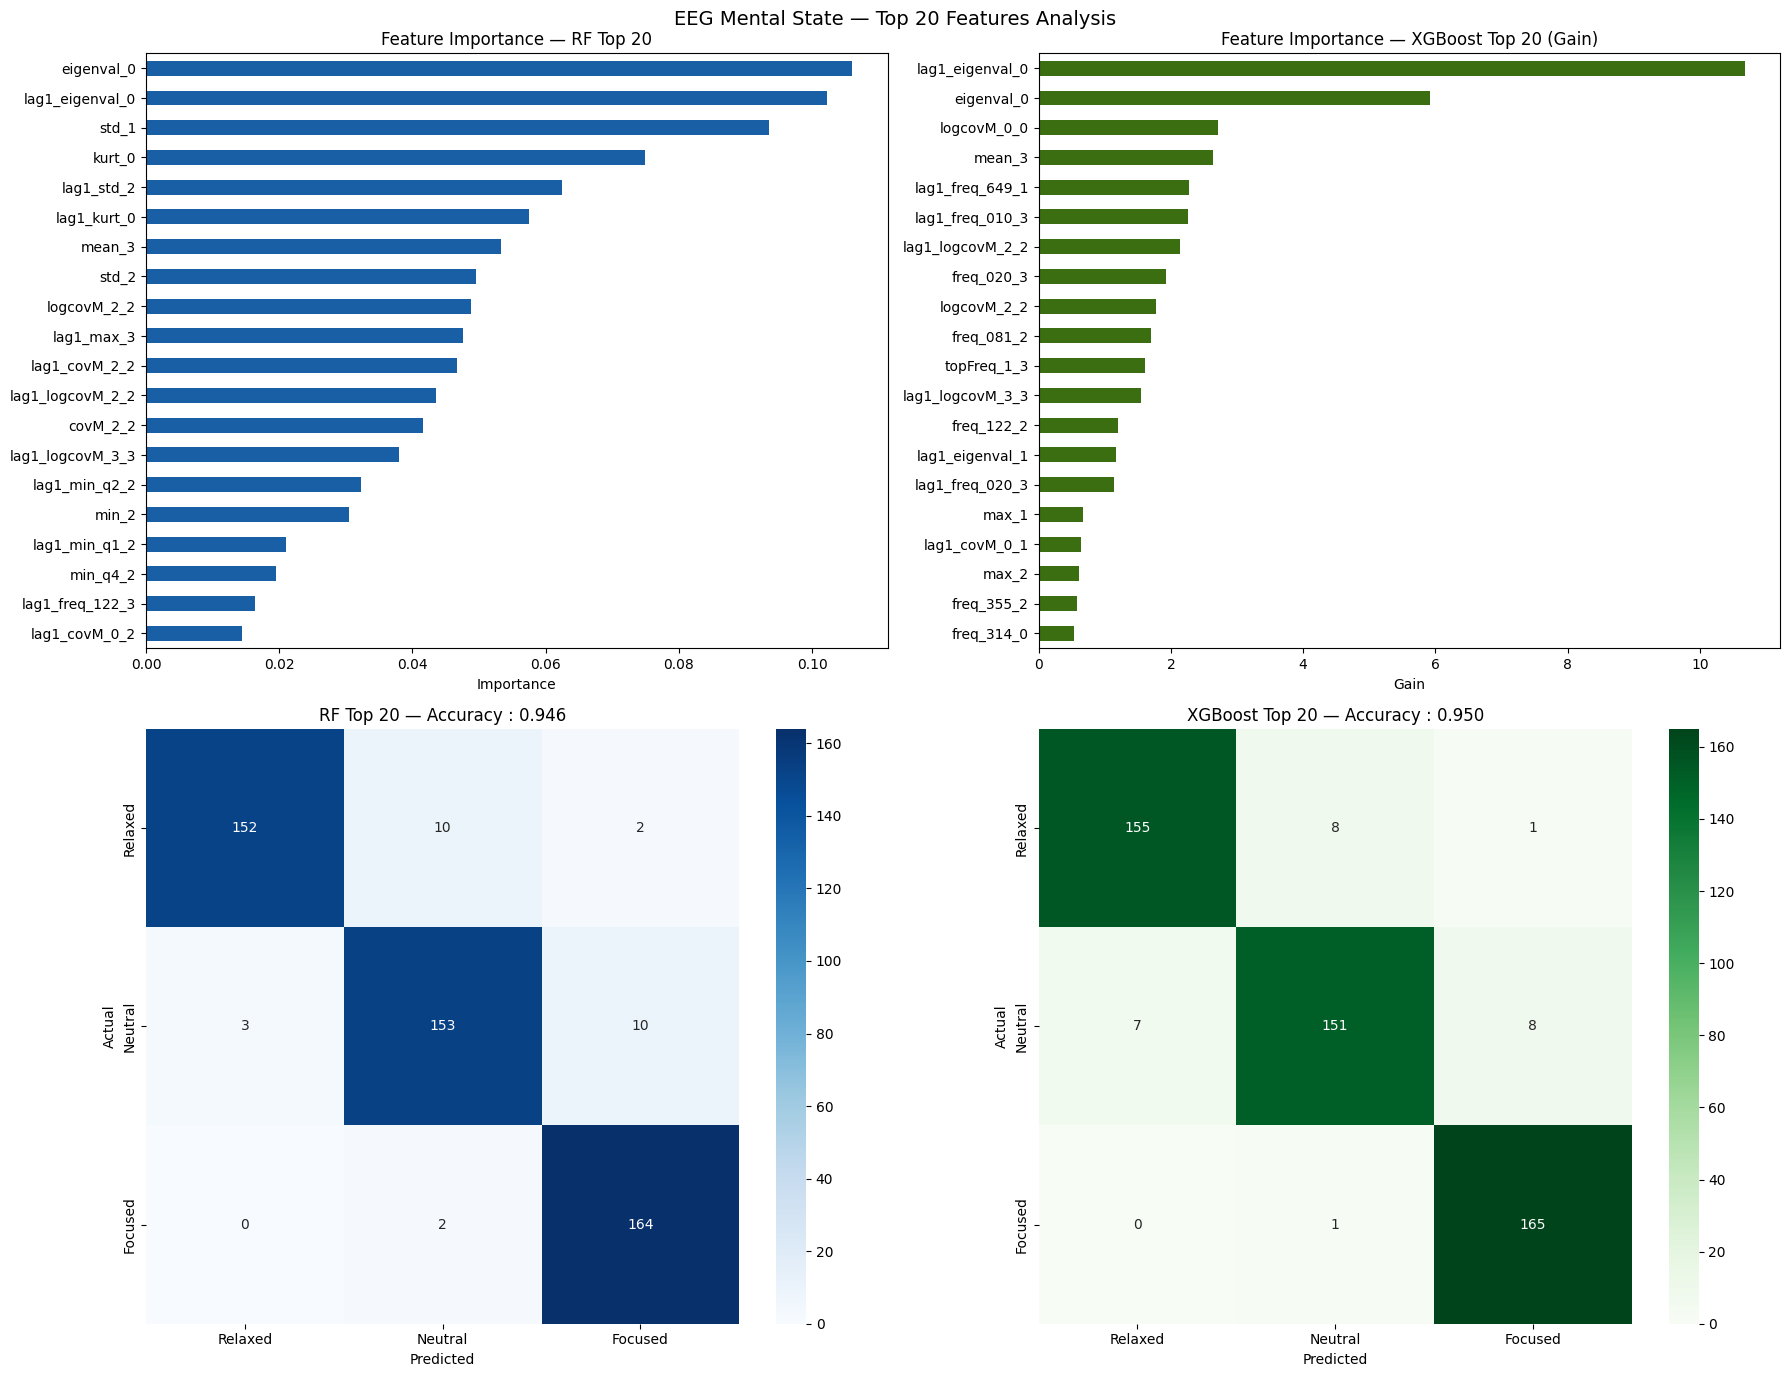

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

state_names = ['Relaxed', 'Neutral', 'Focused']

# ============================================
# 1. FEATURE IMPORTANCE — RF Top 20
# ============================================
rf_top20_model = models_all['RF Top 20']
importances_rf = pd.Series(
    rf_top20_model.feature_importances_,
    index=top20_rf
).sort_values(ascending=True)

importances_rf.plot(kind='barh', ax=axes[0, 0], color='#185FA5')
axes[0, 0].set_title('Feature Importance — RF Top 20', fontsize=12)
axes[0, 0].set_xlabel('Importance')

# ============================================
# 2. FEATURE IMPORTANCE — XGBoost Top 20
# ============================================
importances_xgb = pd.Series(
    models_all['XGBoost Top 20'].get_booster().get_score(importance_type='gain')
).sort_values(ascending=True)

importances_xgb.plot(kind='barh', ax=axes[0, 1], color='#3B6D11')
axes[0, 1].set_title('Feature Importance — XGBoost Top 20 (Gain)', fontsize=12)
axes[0, 1].set_xlabel('Gain')

# ============================================
# 3. CONFUSION MATRIX — RF Top 20
# ============================================
_, X_train_rf, X_test_rf = datasets['RF Top 20']
y_pred_rf_top20 = models_all['RF Top 20'].predict(X_test_rf)

cm_rf = confusion_matrix(y_test_eeg, y_pred_rf_top20)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=state_names, yticklabels=state_names,
            ax=axes[1, 0])
axes[1, 0].set_title(f'RF Top 20 — Accuracy : {accuracy_score(y_test_eeg, y_pred_rf_top20):.3f}')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_xlabel('Predicted')

# ============================================
# 4. CONFUSION MATRIX — XGBoost Top 20
# ============================================
_, X_train_xgb, X_test_xgb = datasets['XGBoost Top 20']
y_pred_xgb_top20 = models_all['XGBoost Top 20'].predict(X_test_xgb)

cm_xgb = confusion_matrix(y_test_eeg, y_pred_xgb_top20)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=state_names, yticklabels=state_names,
            ax=axes[1, 1])
axes[1, 1].set_title(f'XGBoost Top 20 — Accuracy : {accuracy_score(y_test_eeg, y_pred_xgb_top20):.3f}')
axes[1, 1].set_ylabel('Actual')
axes[1, 1].set_xlabel('Predicted')

plt.suptitle('EEG Mental State — Top 20 Features Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('eeg_top20_analysis.png', dpi=150)
plt.show()

In [39]:
# ============================================
# FEATURE IMPORTANCE — RF Top 20 (texte)
# ============================================
print("=== FEATURE IMPORTANCE — RF Top 20 ===")
rf_top20_model = models_all['RF Top 20']
importances_rf = pd.Series(
    rf_top20_model.feature_importances_,
    index=top20_rf
).sort_values(ascending=False)

for i, (feat, val) in enumerate(importances_rf.items(), 1):
    print(f"  {i:>2}. {feat:<35} {val:.4f}")

# ============================================
# FEATURE IMPORTANCE — XGBoost Top 20 (texte)
# ============================================
print("\n=== FEATURE IMPORTANCE — XGBoost Top 20 (Gain) ===")
importances_xgb = pd.Series(
    models_all['XGBoost Top 20'].get_booster().get_score(importance_type='gain')
).sort_values(ascending=False)

for i, (feat, val) in enumerate(importances_xgb.items(), 1):
    print(f"  {i:>2}. {feat:<35} {val:.4f}")

# ============================================
# CONFUSION MATRIX — RF Top 20 (texte)
# ============================================
print("\n=== CONFUSION MATRIX — RF Top 20 ===")
_, _, X_test_rf = datasets['RF Top 20']
y_pred_rf_top20 = models_all['RF Top 20'].predict(X_test_rf)
cm_rf = confusion_matrix(y_test_eeg, y_pred_rf_top20)
print(f"{'':>12} {'Relaxed':>10} {'Neutral':>10} {'Focused':>10}")
for i, row in enumerate(['Relaxed', 'Neutral', 'Focused']):
    print(f"{row:>12} {cm_rf[i][0]:>10} {cm_rf[i][1]:>10} {cm_rf[i][2]:>10}")
print(f"Accuracy : {accuracy_score(y_test_eeg, y_pred_rf_top20):.3f}")

# ============================================
# CONFUSION MATRIX — XGBoost Top 20 (texte)
# ============================================
print("\n=== CONFUSION MATRIX — XGBoost Top 20 ===")
_, _, X_test_xgb = datasets['XGBoost Top 20']
y_pred_xgb_top20 = models_all['XGBoost Top 20'].predict(X_test_xgb)
cm_xgb = confusion_matrix(y_test_eeg, y_pred_xgb_top20)
print(f"{'':>12} {'Relaxed':>10} {'Neutral':>10} {'Focused':>10}")
for i, row in enumerate(['Relaxed', 'Neutral', 'Focused']):
    print(f"{row:>12} {cm_xgb[i][0]:>10} {cm_xgb[i][1]:>10} {cm_xgb[i][2]:>10}")
print(f"Accuracy : {accuracy_score(y_test_eeg, y_pred_xgb_top20):.3f}")

=== FEATURE IMPORTANCE — RF Top 20 ===
   1. eigenval_0                          0.1060
   2. lag1_eigenval_0                     0.1022
   3. std_1                               0.0936
   4. kurt_0                              0.0749
   5. lag1_std_2                          0.0625
   6. lag1_kurt_0                         0.0574
   7. mean_3                              0.0533
   8. std_2                               0.0496
   9. logcovM_2_2                         0.0488
  10. lag1_max_3                          0.0476
  11. lag1_covM_2_2                       0.0467
  12. lag1_logcovM_2_2                    0.0435
  13. covM_2_2                            0.0416
  14. lag1_logcovM_3_3                    0.0379
  15. lag1_min_q2_2                       0.0323
  16. min_2                               0.0305
  17. lag1_min_q1_2                       0.0210
  18. min_q4_2                            0.0196
  19. lag1_freq_122_3                     0.0164
  20. lag1_covM_0_2           

In [40]:
conclusion = """
## Conclusion

This project classified 3 mental states (Relaxed, Neutral, Focused) from EEG signals
using 6 machine learning models on the Mental State dataset (2,479 obs, 988 features).

### Overall Performance

XGBoost achieves the best performance at 97.8% CV accuracy — nearly 3x above the
random baseline (33.3%). All tree-based models (RF, DT, XGBoost) significantly
outperform SVM, which struggles with the high dimensionality of EEG features (988).

### Feature Reduction — Key Finding

Top 20 features out of 988 retain 95%+ accuracy:
- RF  : 96.5% → 94.9% (−1.6%) using 98% fewer features
- XGB : 97.8% → 95.6% (−2.2%) using 98% fewer features

Both RF and XGBoost agree on the most informative features:
- eigenval_0 / lag1_eigenval_0 : eigenvalue of the covariance matrix of channel 0
  → captures the overall variance/energy of the EEG signal
- logcovM_2_2 / lag1_logcovM_2_2 : log-covariance of channel 2
  → reflects brain connectivity dynamics
- mean_3 : mean amplitude of channel 3
  → captures sustained neural activation
- Lagged features (lag1_*) consistently appear in both models
  → temporal dynamics between consecutive windows are highly informative

### Confusion Matrix Analysis

RF Top 20 (Accuracy: 94.6%):
- Focused : 164/166 correct (98.8%) — easiest class to detect
- Relaxed : 152/164 correct (92.7%)
- Neutral : 153/166 correct (92.2%) — most confused with Focused (10 errors)

XGBoost Top 20 (Accuracy: 95.0%):
- Focused : 165/166 correct (99.4%) — near perfect
- Relaxed : 155/164 correct (94.5%)
- Neutral : 151/166 correct (90.9%) — most confused with Relaxed (7) and Focused (8)

→ Neutral is the hardest class to classify — physiologically intermediate
  between Relaxed and Focused states.
→ Focused is the easiest — strong distinctive EEG signatures (high beta waves).

### Limitations
- Only 2 subjects → limited generalizability
- Lag features may introduce temporal leakage without chronological split
- SVM requires dimensionality reduction (PCA/UMAP) to be competitive

### Next Steps
- Chronological train/test split to prevent temporal leakage
- Apply PCA before SVM
- Test on larger datasets (SEED, DEAP)
- Explore deep learning (EEGNet, CNN-LSTM)
"""

print(conclusion)


## Conclusion

This project classified 3 mental states (Relaxed, Neutral, Focused) from EEG signals
using 6 machine learning models on the Mental State dataset (2,479 obs, 988 features).

### Overall Performance

XGBoost achieves the best performance at 97.8% CV accuracy — nearly 3x above the
random baseline (33.3%). All tree-based models (RF, DT, XGBoost) significantly
outperform SVM, which struggles with the high dimensionality of EEG features (988).

### Feature Reduction — Key Finding

Top 20 features out of 988 retain 95%+ accuracy:
- RF  : 96.5% → 94.9% (−1.6%) using 98% fewer features
- XGB : 97.8% → 95.6% (−2.2%) using 98% fewer features

Both RF and XGBoost agree on the most informative features:
- eigenval_0 / lag1_eigenval_0 : eigenvalue of the covariance matrix of channel 0
  → captures the overall variance/energy of the EEG signal
- logcovM_2_2 / lag1_logcovM_2_2 : log-covariance of channel 2
  → reflects brain connectivity dynamics
- mean_3 : mean amplitude of channel 3
